# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Handling Missing Values](#handling-missing-values)
3. [Feature Distributions](#feature-distributions)
4. [Possible Biases](#possible-biases)
5. [Correlations](#correlations)


In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

sns.set_theme(style="whitegrid")


## Dataset Overview

This dataset is derived from the National Supported Work (NSW) Demonstration, famously analyzed by Robert LaLonde (1986) and later by Dehejia and Wahba (1999) to benchmark causal inference and econometric models. The data was loaded directly from the MatchIt package repository.

DATASET CHARACTERISTICS:
* Number of Samples: 614 observations. This specific subset contains individuals who received the job training (treated) combined with a non-experimental comparison group (control).  
* Number of Features: 9 variables (including the target and treatment indicators).

STRUCTURE OF THE DATASET: 
* Target Variable: re78 (Real annual earnings in 1978, post-treatment).  
* Treatment Indicator: treat (1 if the individual received the job training intervention, 0 if they were in the control group).  
* Pre-Treatment Covariates: 7 demographic and historical earnings features used to control for confounding bias. These include age, education (educ), race (black, hisp), marital status (married), educational attainment (nodegr), and historical pre-training earnings (re74, re75).

In [9]:
# Load the data
df = sm.datasets.get_rdataset("lalonde", "MatchIt").data

# Number of samples
num_samples = df.shape[0]

# Number of features
num_features = df.shape[1]

# Display these dataset characteristics
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}\n")

# Display the first few rows of the dataframe to show the structure
print("Example data:")
display(df.head())

# Show basic data types and info
print("\nDataset Info:")
display(df.info())

Number of samples: 614
Number of features: 9

Example data:


,treat,age,educ,race,married,nodegree,re74,re75,re78
rownames,,,,,,,,,
NSW1,1,37,11,black,1,1,0.0,0.0,9930.0460
NSW2,1,22,9,hispan,0,1,0.0,0.0,3595.8940
NSW3,1,30,12,black,0,0,0.0,0.0,24909.4500
NSW4,1,27,11,black,0,1,0.0,0.0,7506.1460
NSW5,1,33,8,black,0,1,0.0,0.0,289.7899



Dataset Info:
<class 'pandas.DataFrame'>
Index: 614 entries, NSW1 to PSID429
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   treat     614 non-null    int64  
 1   age       614 non-null    int64  
 2   educ      614 non-null    int64  
 3   race      614 non-null    str    
 4   married   614 non-null    int64  
 5   nodegree  614 non-null    int64  
 6   re74      614 non-null    float64
 7   re75      614 non-null    float64
 8   re78      614 non-null    float64
dtypes: float64(3), int64(5), str(1)
memory usage: 48.0+ KB


None

## Handling Missing Values

An analysis of the dataset revealed that it is entirely complete. There are 0 missing or null values across all features and target variables, so no imputation or row-dropping was necessary


In [10]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values


treat       0
age         0
educ        0
race        0
married     0
nodegree    0
re74        0
re75        0
re78        0
dtype: int64

## Feature Distributions

[Plot the distribution of various features and target variables. Comment on the skewness, outliers, or any other observations.]


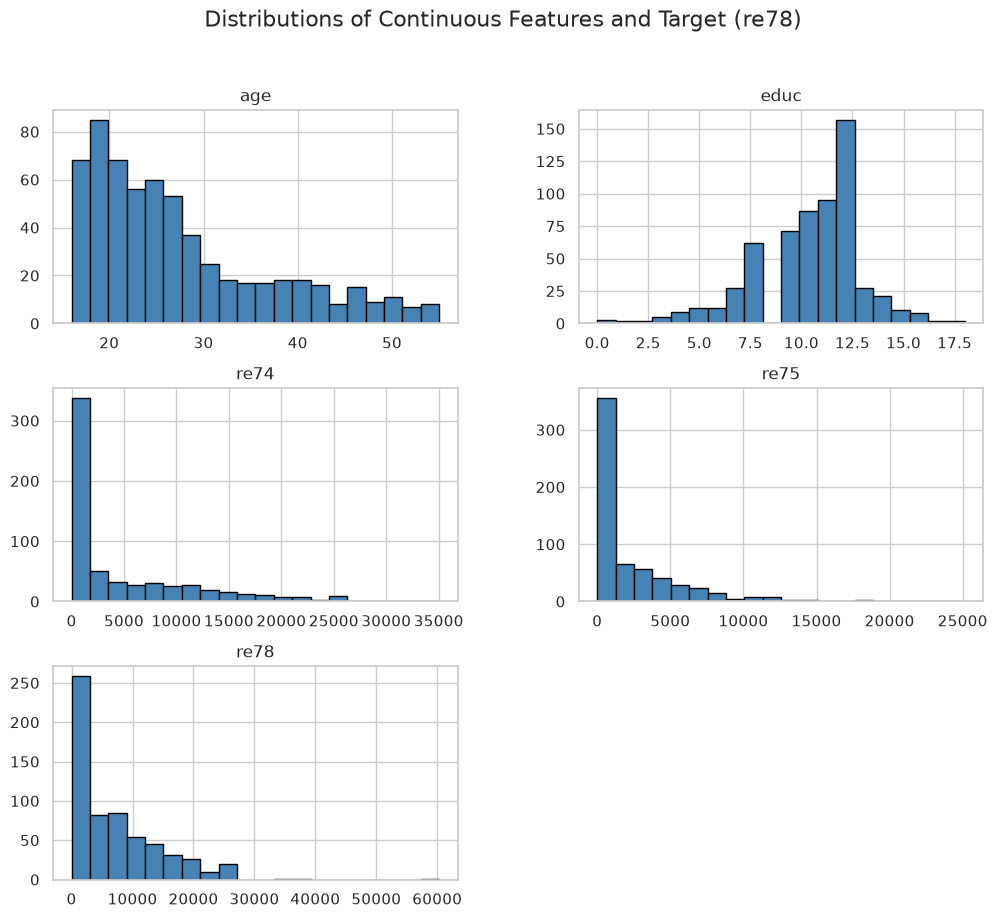

/tmp/ipykernel_18042/2019760879.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[i//2, i%2], x=feature, data=df, palette='Set2')
/tmp/ipykernel_18042/2019760879.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[i//2, i%2], x=feature, data=df, palette='Set2')
/tmp/ipykernel_18042/2019760879.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[i//2, i%2], x=feature, data=df, palette='Set2')
/tmp/ipykernel_18042/2019760879.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wi

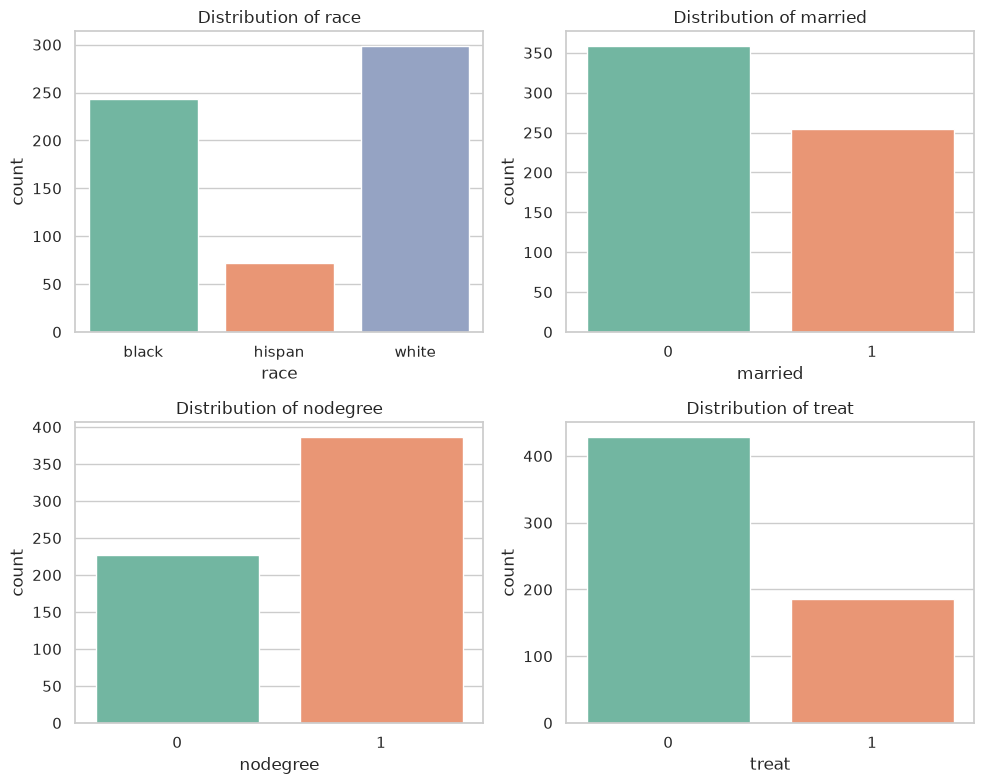

In [12]:
# Plotting histograms of continuous features and the target variable (re78)
continuous_features = ['age', 'educ', 're74', 're75', 're78']

df[continuous_features].hist(figsize=(12, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distributions of Continuous Features and Target (re78)', fontsize=16)
plt.show()

# Visualizing the categorical/binary features (Updated for the MatchIt column names!)
categorical_features = ['race', 'married', 'nodegree', 'treat']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, feature in enumerate(categorical_features):
    sns.countplot(ax=axes[i//2, i%2], x=feature, data=df, palette='Set2')
    axes[i//2, i%2].set_title(f'Distribution of {feature}')
    
plt.tight_layout()
plt.show()


## Possible Biases

[Investigate the dataset for any biases that could affect the model’s performance and fairness (e.g., class imbalance, historical biases).]


In [ ]:
# Example: Checking for class imbalance in a classification problem
# sns.countplot(x='target_variable', data=df)

# Your code to investigate possible biases goes here


## Correlations

[Explore correlations between features and the target variable, as well as among features themselves.]


In [ ]:
# Example: Plotting a heatmap to show feature correlations
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.show()
